In [1]:
from dlfs.base import Module, Loss, Optimizer
from dlfs.layers import DenseLayer, ReshapeLayer, ConvLayer, ConvTransposeLayer, BatchNorm2D, DropoutLayer
from dlfs.activation import ReLU, LeakyReLU, Tanh, Sigmoid
from dlfs.modules import SequentialWrapper
from dlfs.helpers import DLFSData, get_random_batch
from dlfs.optimizers import Optimizer_Adam
from dlfs.loss import BCE_Loss, MSE_Loss

import numpy as np
import matplotlib.pyplot as plt

# Generative Adversarial Network - GAN

- generative model in which two networks, discriminator and generator, compete to outsmart the adversary

- generator attempts to create convincing samples to fool discriminator

- discriminator attempts to correctly classify whether generator samples are real or fake

- if training is successful, generator is able to generate new samples similar to input data

In [2]:
class DCGenerator(Module):

    def __init__(self, latent_dim: int, features: int) -> None:
        """
        Deep Convolutional Generator.

        Parameters
        ----------
        latent_dim : int
            Number of latent space image channels.

        features : int
            Base number of input/output channels for each transpose convolutional layer.
        """

        self.latent_dim = latent_dim
        self.features = features
    
        self.model = SequentialWrapper([

                # Z → 4 × 4
                ConvTransposeLayer(
                    input_channels=latent_dim,
                    output_channels=features * 4,
                    kernel_size=4,
                    stride=1,
                    padding=0
                ),
                BatchNorm2D(features * 4),
                ReLU(),

                # 4×4 → 7×7
                ConvTransposeLayer(
                    input_channels=features * 4,
                    output_channels=features * 2,
                    kernel_size=3,
                    stride=2,
                    padding=1
                ),
                BatchNorm2D(features * 2),
                ReLU(),

                # 7×7 → 14×14
                ConvTransposeLayer(
                    input_channels=features * 2,
                    output_channels=features,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                BatchNorm2D(features),
                ReLU(),

                # 14×14 → 28×28
                ConvTransposeLayer(
                    input_channels=features,
                    output_channels=1,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),

                #Sigmoid()
            ])

    def forward(self, z: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Generator. Creates output attribute.

        Parameters
        ----------
        z : np.ndarray
            Array of random latent samples of shape (B, latent_dim, 1, 1).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        None
        """
        self.model.forward(z, training=training)
        self.output = self.model.output

    def backward(self, delta: np.ndarray) -> None:
        """
        Backward pass for the Generator. Creates gradient attribute.

        Parameters
        ----------
        delta : np.ndarray
            Upstream gradient of shape (B, C, H, W).

        Returns
        -------
        None
        """
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [3]:
class DCDiscriminator(Module):

    def __init__(self, features: int) -> None:
        """
        Deep Convolutional Discriminator.

        Parameters
        ----------
        features : int
            Base number of input/output channels for each convolutional layer.
        """

        self.features = features

        self.model = SequentialWrapper([
                ConvLayer(input_channels=1, output_channels=features, kernel_size=4, stride=2, padding=1),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features, output_channels=features*2, kernel_size=4, stride=2, padding=1),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features*2, output_channels=features*4, kernel_size=3, stride=2, padding=1),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features*4, output_channels=1, kernel_size=4, stride=1, padding=0),
                ReshapeLayer(input_shape=(1, 1, 1), output_shape=(1, )),
                #Sigmoid()
        ])
    
    def forward(self, x: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Discriminator. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input array of images of shape (B, C, H, W).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        None
        """
        self.model.forward(x, training=training)
        self.output = self.model.output

    def backward(self, delta: np.ndarray) -> None:
        """
        Backward pass for the Discriminator. Creates gradient attribute.

        Parameters
        ----------
        delta : np.ndarray
            Upstream gradient of shape (B, ).

        Returns
        -------
        None
        """
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [4]:
class GAN(Module):

    def __init__(self, generator: Module, discriminator: Module, loss_fn: Loss, optimizer_g: Optimizer, optimizer_d: Optimizer):
        """
        Generative Adversarial Network. Consists of generator and discriminator networks.

        Parameters
        ----------
        generator : Module
            Generator network.
        
        discriminator : Module
            Discriminator network.

        loss_fn : Loss
            Loss function used during training.

        optimizer_g : Optimizer
            Generator optimizer used during training.

        optimizer_d : Optimizer
            Discriminator optimizer used during training.
        """
        self.generator = generator
        self.discriminator = discriminator
        self.loss_fn = loss_fn
        self.optimizer_g = optimizer_g
        self.optimizer_d = optimizer_d

    def _generator_forward_step(self, batch_size: int, real_labels: np.ndarray, training: bool = False) -> tuple(float, np.ndarray):
        """
        Generator forward helper method.

        Parameters
        ----------
        batch_size : int
            Number of samples to generate.

        real_labels : np.ndarray
            Array of true labels (1s) of shape (B, 1).

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        generator_loss, discriminator_output : tuple(float, np.ndarray) 
        """
        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim, 1, 1)

        # Generate fake samples
        self.generator.forward(z, training=training)
        generated_fake = self.generator.output.copy()

        # Let discriminator guess
        self.discriminator.forward(generated_fake, training=training)
        discriminator_output = self.discriminator.output.copy() #(B, 1)

        # Calculate generator loss (compare fake output with real labels)
        generator_loss = self.loss_fn.calculate(discriminator_output, real_labels)

        return generator_loss, discriminator_output.copy()

    def _generator_backward_step(self, discriminator_output: np.ndarray, real_labels: np.ndarray) -> None:
        """
        Generator backward helper method. Creates generator gradient attribute.

        Parameters
        ----------
        discriminator_output : np.ndarray
            Array of predicted labels from discriminator.

        real_labels : np.ndarray
            Array of true labels (1s) of shape (B, 1).

        Returns
        -------
        None
        """
        self.loss_fn.backward(discriminator_output, real_labels)
        self.discriminator.backward(self.loss_fn.dinputs)
        self.generator.backward(self.discriminator.dinputs)

    def _discriminator_forward_step(self, X: np.ndarray, 
                                          real_labels: np.ndarray, 
                                          fake_labels: np.ndarray, 
                                          noise: float = 0.1, 
                                          training: bool = False) -> tuple(float, np.ndarray, np.ndarray):
        """
        Discriminator forward helper method.

        Parameters
        ----------
        X : np.ndarray
            Original data for discriminator.

        real_labels : np.ndarray
            Array of true labels (1s) of shape (B, 1).

        fake_labels : np.ndarray
            Array of false labels (0s) of shape (B, 1).

        noise : float, default=0.1
            Noise added to input data. Used during training to weaken discriminator.

        training : bool, default=False
            Flag indicating whether module is in training mode, used for API consistency.

        Returns
        -------
        discriminator_loss, combined_output, y_combined : tuple(float, np.ndarray, np.ndarray) 
        """

        # Extract batch size from X
        batch_size = X.shape[0]

        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim, 1, 1)

        # Generate fake samples
        self.generator.forward(z, training=training)
        generated_fake = self.generator.output.copy()

        # Combine real and fake samples
        X_combined = np.concatenate([X, generated_fake])
        y_combined = np.concatenate([real_labels, fake_labels]) 

        # Shuffle real and fake samples
        idx = np.random.permutation(len(X_combined))
        X_combined = X_combined[idx]
        y_combined = y_combined[idx]

        # Add Gaussian noise to samples
        X_combined += np.random.randn(*X_combined.shape) * noise

        # Let discriminator guess both real and fake
        self.discriminator.forward(X_combined, training=training)
        combined_output = self.discriminator.output.copy() #(B, 1)

        # Calculate discriminator loss
        discriminator_loss = self.loss_fn.calculate(combined_output, y_combined)
        return discriminator_loss, combined_output.copy(), y_combined.copy()

    def _discriminator_backward_step(self, discriminator_output: np.ndarray, labels: np.ndarray) -> None:
        """
        Discriminator backward helper method. Creates discriminator gradient attribute.

        Parameters
        ----------
        discriminator_output : np.ndarray
            Array of predicted labels from discriminator.

        labels : np.ndarray
            Array of both true and false labels of shape (B, 1).

        Returns
        -------
        None
        """
        self.loss_fn.backward(discriminator_output, labels)
        self.discriminator.backward(self.loss_fn.dinputs)
    
    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None) -> None:
        """
        Train the GAN for a specified number of epochs.

        Parameters
        ----------
        X : np.ndarray
            Input image data of shape (n_samples, C, H, W).

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        Returns
        -------
        None
        """

        for i in range(epochs + 1):

            if batch_size is None:
                batch_size = X.shape[0]

            X_batch = get_random_batch(X, batch_size=batch_size)[0]

            # Create real labels (1s) and fake labels (0s)
            real = np.ones((batch_size, 1))
            fake = np.zeros((batch_size, 1))

            # Discriminator forward-backward step
            dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X_batch, 
                                                                                  real * 0.9, # Label smoothing, used to weaken discriminator
                                                                                  fake, 
                                                                                  noise=0.1, # Adding noise to input data, used to weaken discriminator
                                                                                  training=True)
            self._discriminator_backward_step(dis_out, combined_labels)

            # Discriminator parameter update
            self.optimizer_d.pre_update_parameters()
            self.optimizer_d.update_parameters(self.discriminator)
            self.optimizer_d.post_update_parameters()

            # Train generator
            for _ in range(1):
                
                # Generator forward-backward step
                gen_loss, dis_out = self._generator_forward_step(batch_size, real, training=True)
                self._generator_backward_step(dis_out, real)

                # Generator parameter update
                self.optimizer_g.pre_update_parameters()
                self.optimizer_g.update_parameters(self.generator)
                self.optimizer_g.post_update_parameters()

            if print_every is not None:

                # Create validation labels for whole dataset
                real = np.ones((X.shape[0], 1))
                fake = np.zeros((X.shape[0], 1))

                # Validation Gen
                gen_loss, dis_out = self._generator_forward_step(X.shape[0], real)

                # Validation Disc
                dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X, real, fake, noise=0.0)

                if not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS DIS : {dis_loss:.5f} ===== LOSS GEN : {gen_loss:.5f}')

# Load data

In [5]:
np.random.seed(1) # set seed for reproducibility

mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [6]:
# Selecting images of 0s, 1s, 2s and 3s
X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0, 1, 2, 3], limit=50, shuffle=True)
X_train = DLFSData.normalize_MNIST(X_train, range=(-1, 1))

X_train = X_train.reshape(-1, 1, 28, 28)
print(f'X_train: {X_train.shape}')

X_train: (200, 1, 28, 28)


In [7]:
latent_dim = 100
generator_features = 64
discriminator_features = 32

lr = 2e-3
epochs = 500
batch_size = 100

gen = DCGenerator(latent_dim=latent_dim, features=generator_features)
dis = DCDiscriminator(features=discriminator_features)

gan = GAN(generator=gen, 
          discriminator=dis, 
          loss_fn=BCE_Loss(from_logits=True),
          optimizer_g=Optimizer_Adam(learning_rate=lr, beta_1=0.5),
          optimizer_d=Optimizer_Adam(learning_rate=lr, beta_1=0.5)) # For GANs, Adam beta_1 is 0.5

gan.train(X_train, epochs=epochs, print_every=50, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS DIS : 0.63795 ===== LOSS GEN : 0.50533
===== EPOCH : 50 ===== LOSS DIS : 0.50768 ===== LOSS GEN : 0.79702
===== EPOCH : 100 ===== LOSS DIS : 0.53644 ===== LOSS GEN : 0.87684
===== EPOCH : 150 ===== LOSS DIS : 0.45148 ===== LOSS GEN : 1.27185
===== EPOCH : 200 ===== LOSS DIS : 0.39077 ===== LOSS GEN : 1.34887
===== EPOCH : 250 ===== LOSS DIS : 0.44808 ===== LOSS GEN : 1.04906
===== EPOCH : 300 ===== LOSS DIS : 0.36972 ===== LOSS GEN : 1.69769
===== EPOCH : 350 ===== LOSS DIS : 0.42260 ===== LOSS GEN : 1.37520
===== EPOCH : 400 ===== LOSS DIS : 0.36651 ===== LOSS GEN : 1.31711
===== EPOCH : 450 ===== LOSS DIS : 0.36053 ===== LOSS GEN : 1.21455
===== EPOCH : 500 ===== LOSS DIS : 0.42529 ===== LOSS GEN : 1.64704


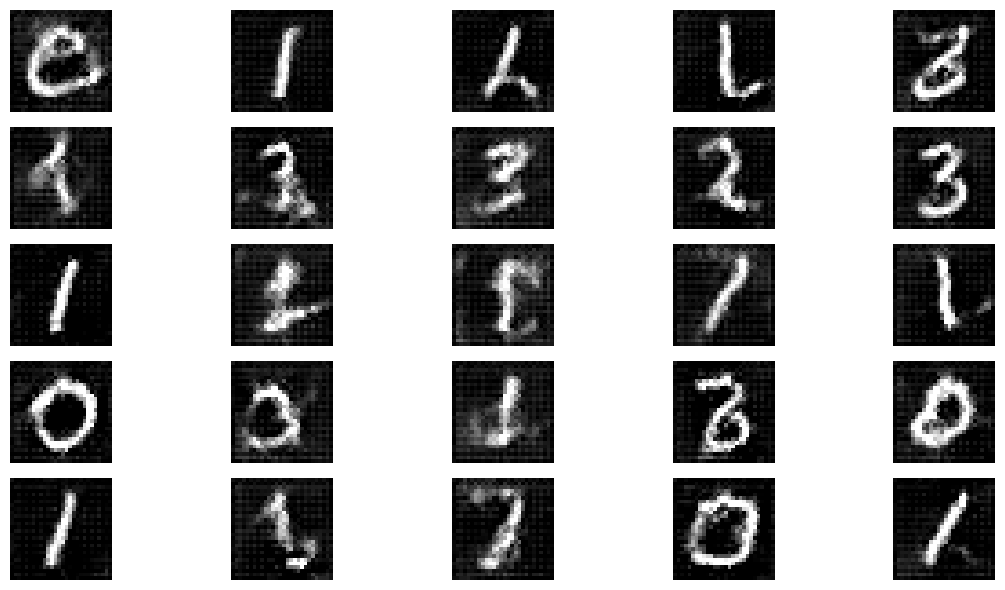

In [13]:
num_img = 25

fig, axes = plt.subplots(5, 5, figsize=(12, 6))
axes = axes.flatten()

# Sample random latent Z
Z = np.random.randn(num_img, gan.generator.latent_dim, 1, 1)

# Pass through generator to generate new samples
gan.generator.forward(Z)

# Denormalize to [0, 255]
gan.generator.output = DLFSData.denormalize_MNIST(gan.generator.output, range=(-1, 1))

for i in range(num_img):
    img = gan.generator.output[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()